In [1]:
title = "# Random variables and probability distributions: Exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Random variables and probability distributions: Exercises

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$

### Exercises 1

Sample from the distribution with PDF
$$
    p(x) = \begin{cases}
                0 & x < 0 \\
                \frac{1}{2}\sin x & \text{otherwise} \\
                0 & x > \pi
            \end{cases}
$$
- Plot the PDF and CDF
- Sample from the distribution using invere transform sampling
- Compare the histogram of the samples to the PDF


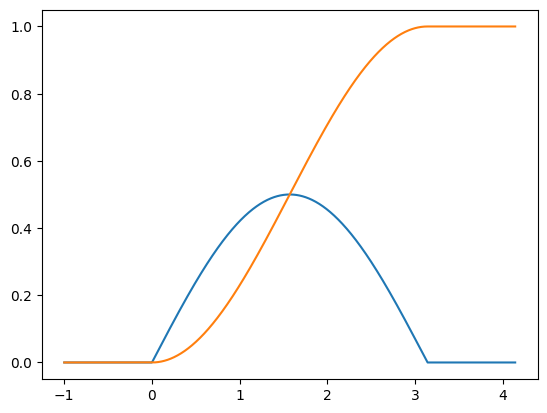

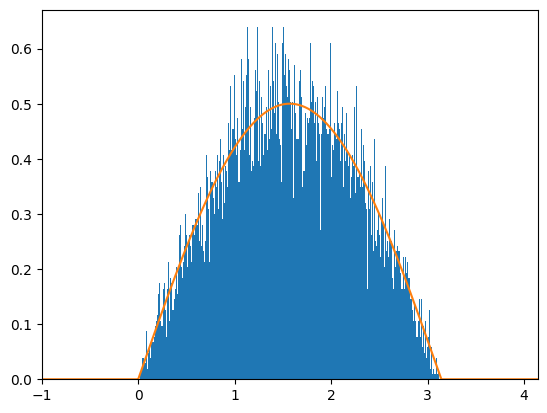

In [2]:
# exercise 1

# normalized to one

import numpy as np
import matplotlib.pyplot as plt

def prob(xs):
    xs = np.where(((xs < 0) | (xs > np.pi)), 0, 0.5 * np.sin(xs))
    return xs


x = np.linspace(-1, np.pi+1, 1000)

prob_x = prob(xs=x)

plt.plot(x,prob_x)
plt.show

def cdf(xs):
    cond_list = [
        xs < 0,
        xs > np.pi,
    ]
    choice_list = [
        0,
        1,
    ]

    xs = np.select(condlist= cond_list, choicelist=choice_list, default=-0.5 * np.cos(xs) + 0.5)
    return xs

cdf_x = cdf(xs = x)

plt.plot(x, cdf_x)
plt.show()


def inverse_cdf(n_samples):
    a = np.random.rand(n_samples)
    
    cond_list = [
            a == 0,
            a == 1,
        ]
    choice_list = [
        0,
        np.pi,
    ]
    a = np.select(condlist= cond_list, choicelist=choice_list, default=np.arccos(-2*a+1))
    return a

my_xs = inverse_cdf(10000)

plt.hist(my_xs, bins= 300, density= True)
plt.xlim(-1, np.pi+1)
plt.plot(x,prob_x)
plt.show()


    







In [3]:
# prob(x) = 1/2 sin(x)
# arcsin(2prob(x)) = x

### Exercise 2

Show the expressions for the mean and variance:

- For some constant $a$: $E[x + a] = \mu + a$
- For some constant $c$: $E[cx] = c\mu$

- $\Var[x] = E[(x - E[x])^2] = E[x^2] - E[x]^2$
- For some constant $a$: $\Var[x + a] = \sigma^2$
- For some constant $c$: $\Var[cx] = c^2\sigma^2$

1.

 $E[x+a] = \frac{1}{N} \sum_{i=0}^{N-1}(x_i + a) = \frac{1}{N} \sum_{i=0}^{N-1}(x_i) + \frac{1}{N} \sum_{i=0}^{N-1}(a) = \frac{1}{N} \sum_{i=0}^{N-1}(x_i) + \frac{N\cdot a}{N} = \mu + a$

2. 

$E[cx] = \frac{1}{N} \sum_{i=0}^{N-1}(c\cdot x_i) = c \cdot \frac{1}{N} \sum_{i=0}^{N-1}(x_i) = c \cdot \mu$

3. 

$ \Var[x] = E[(x - E[x])^2] = \frac{1}{N} \sum_{i=0}^{N-1}\left(x_i - \frac{1}{N} \sum_{i=0}^{N-1}(x_i)\right)^2 =  \frac{1}{N} \sum_{i=0}^{N-1}\left(x_i^2 -2 x_i \frac{1}{N} \sum_{i=0}^{N-1}(x_i) + \left(\frac{1}{N} \sum_{i=0}^{N-1}(x_i) \right)^2\right) = \frac{1}{N} \sum_{i=0}^{N-1}(x_i^2) - \frac{2\mu}{N} \sum_{i=0}^{N-1}(x_i) + \frac{1}{N} \sum_{i=0}^{N-1} \mu^2 = E[x^2] - 2\mu^2 + \mu^2 = E[x^2] - E[x]^2$

4.

$\Var[x+a] = E[((x+a) - E(x+a))^2] = E[(x+a-E[x]-a)^2] = E[(x - E[x])^2] = \sigma^2$

5.

$\Var[cx] = E[(cx - E(cx))^2] = E[(c\cdot(x-E[x]))^2] = c^2\cdot E[(x - E[x])^2] = c^2\sigma^2$


### Exercises 3

- Confirm by simulation that the probability of $k$ out of $n$ iid $X_i\sim\Uniform(0,1)$ being in a small interval $\Delta x$ follows a Poisson distribution.
- Derive the Poisson distribution from the binomial distribution.

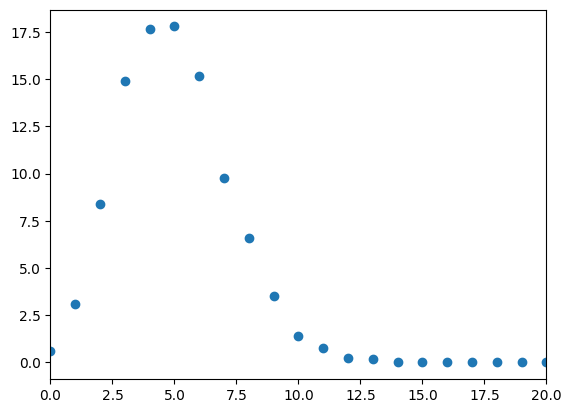

In [7]:
n = 100
dx = 0.05

values = np.random.rand(10000,n)

dist = np.where(values < dx, 1, 0)
sum = np.sum(dist, axis=1)


distris = np.bincount(sum, minlength=n+1) / n
    
plt.scatter(np.arange(n+1), distris)
plt.xlim(0, 20)
plt.show()





$Pr(X=k) = \binom{n}{k}\cdot p^k \cdot (1-p)^{(n-k)}$

$\lim_{n \to \infty} Pr(X=k) = \lim_{n \to \infty} \binom{n}{k}\cdot p^k \cdot (1-p)^{(n-k)} =\lim_{n \to \infty} \frac{n!}{k!(n-k)!}\cdot p^k \cdot (1-p)^{(n-k)} = \lim_{n \to \infty} \frac{n!}{k!(n-k)!}\cdot \frac{\lambda}{n}^k \cdot (1-\frac{\lambda}{n})^{(n-k)} $

$ = \frac{\lambda^k}{k!}\cdot \lim_{n \to \infty} \frac{n!}{(n-k)!} (1-\frac{\lambda}{n})^{n} \cdot (1-\frac{\lambda}{n})^{-k}$

$ = \frac{\lambda^k}{k!}\cdot 1 \cdot exp(-\lambda) \cdot 1 $

$ = \frac{\lambda^k}{k!}\cdot e^{-\lambda}$

### Exercises 4

- Make plots of the PDFs of the distributions we covered so far, varying their parameters
- Compute the distribution of the sum of two independent Gaussian RVs.
- What is the distribution of the sum of two independent RVs $X\sim f$ and $Y\sim g$?
- Derive the PDF of the $\chi^2_{\nu=1}$ distribution
- Bonus:
    - What is the product of two independent RVs $U$ and $V$?
    - Compute the distribution of the ratio of two Gaussian RVs.


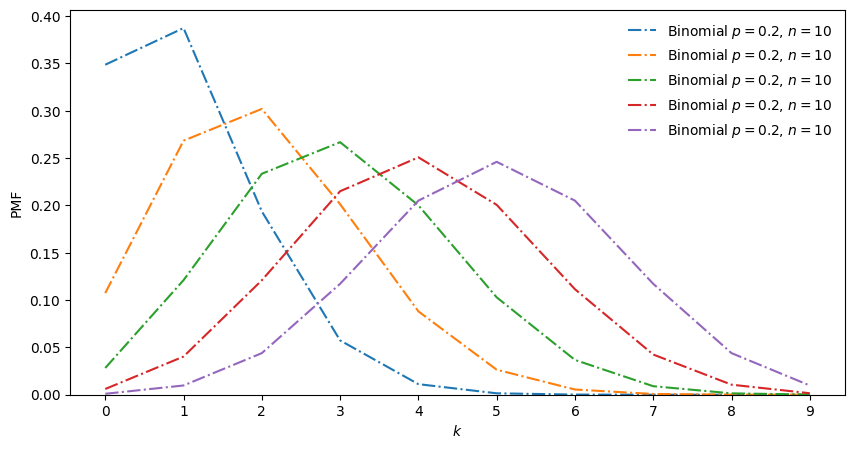

In [ ]:
import scipy.stats

p = [0.1, 0.2, 0.3, 0.4, 0.5]
plt.subplots(figsize=(10, 5))
for i in p:
    distr = scipy.stats.binom(p=i, n=10)
    k = np.arange(10)
    plt.plot(k, distr.pmf(k), linestyle = "dashdot", label=f"Binomial p={i}, n=10")
    plt.ylim(bottom=0)
    plt.legend(frameon=False)
    plt.xticks(k)
    plt.ylabel("PMF")
    plt.xlabel("$k$");
plt.show()

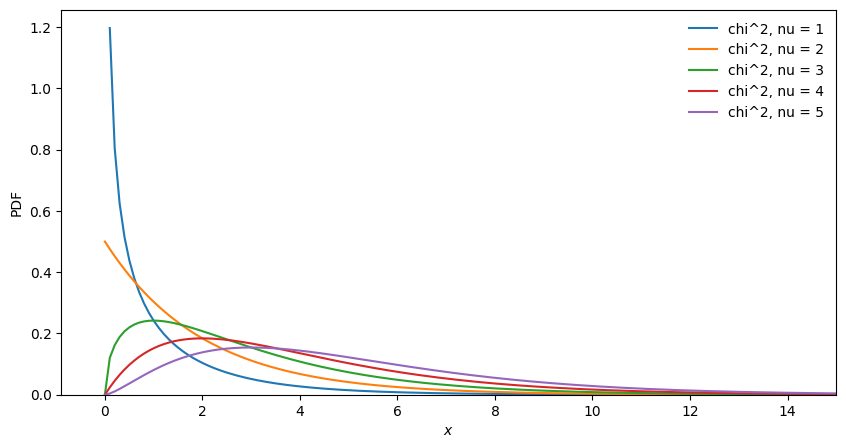

In [16]:
df = [1, 2, 3, 4, 5]
plt.subplots(figsize=(10, 5))
for i in df:
    distr = scipy.stats.chi2(df=i)
    x = np.linspace(0, 20, 200)
    plt.plot(x, distr.pdf(x), label=f"chi^2, nu = {i}")
    plt.ylim(bottom=0)
    plt.xlim(right=15)
    plt.legend(frameon=False)
    # plt.xticks(k)
    plt.ylabel("PDF")
    plt.xlabel("$x$");

### 4.2.

$E[X] + E[Y] = \mu_x + \mu_y$

$Var[X] + Var[Y] = \sigma_x^2 + \sigma_y^2$

based on 4.3:

$Pr(z) = \int^{\infty}_{-\infty}{f(x)g(z-x)dx}$
$= \int^{\infty}_{-\infty}{N(\mu_x, \sigma_x^2)(x)N(\mu_y, \sigma_y^2)(z-x)dx} = N(\mu_x + \mu_y, \sigma_x^2 + \sigma_y^2)$

### 4.3.

for X ~ f and Y ~ g:

e.g. X = x and Y = z - x = y

-> f(x)g(z-x)

$Pr(z) = \int^{\infty}_{-\infty}{f(x)g(z-x)dx} = f*g \ (convolution)$

### 4.4

The square of a normally distributed RV $X \sim \Norm(0, 1)$ is chi-squared distributed with 1 degree of freedom. 

The sum of the squares of $n$ iid $X_i \sim \Norm(0, 1)$ is chi-squared distributed with $n$ degrees of freedom: $\sum_i^n X_i^2 \sim \chi^2_n$

The pdf of the chi-squared distribution with $\nu$ degrees of freedom is
$$
p(x) = \frac{1}{2^\frac{\nu}{2}\Gamma(\frac{\nu}{2})}x^{\frac{\nu}{2}-1}\ee^{-\frac{x}{2}}
$$
- Parameter:
    - $\nu$: number of degrees of freedom
- Symbol: $\chi^2_\nu$
- Mean: $\nu$
- Variance: $2\nu$

Approaches a normal distribution for large $\nu$.


for 1D lol

$\Chi_i^2 = [N(0, 1)]^2 = \left[\frac{1}{\sqrt{2 \pi}} \cdot exp\left(-\frac{x^2}{2}\right)\right]^2 $

$ Y \approx X^2 \ hence \ y \approx (-\sqrt{x})^2, (+\sqrt{x})^2$



X ~ f, Y ~ g

X + Y ~ f + g